<a href="https://colab.research.google.com/github/VishalChauhan85/Video-Game-Sales-EDA-Capstone/blob/main/Video_Game_Sales_%26_Metacritic_Intelligence_(Vishal_Chauhan).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA on Video Game Sales & Metacritic Intelligence (1980–2026)
##### **Contribution**    - Individual (Vishal Chauhan)


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/VishalChauhan85

# **Problem Statement**


The video game industry is highly competitive, with massive development costs and significant financial risks. Stakeholders and publishers often struggle to determine which combinations of game genres, platforms, and developer studios yield the highest probability of commercial success (Global Sales) and critical acclaim (Metacritic Scores) in an ever-evolving market spanning over four decades.

#### **Define Your Business Objective?**

The primary objective is to analyze historical video game data (1980–2026) to uncover the key drivers of a game's success. By evaluating relationships between platform generations, genres, and developer performance, the goal is to provide data-backed, actionable insights to stakeholders. These insights will help optimize future budget allocation, minimize financial risk, and maximize ROI for upcoming game development projects.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
file_path="/content/drive/MyDrive/AIML/games-selected-columns.csv"
df = pd.read_csv(file_path)

### Dataset First View

In [9]:
display(df.head())

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software


### Dataset Rows & Columns count

In [10]:
df.shape

(50000, 10)

### Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   game_id              50000 non-null  object
 1   title                50000 non-null  object
 2   platform             50000 non-null  object
 3   platform_type        50000 non-null  object
 4   platform_maker       50000 non-null  object
 5   platform_generation  50000 non-null  int64 
 6   genre                50000 non-null  object
 7   year                 50000 non-null  int64 
 8   publisher            50000 non-null  object
 9   developer            50000 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


#### Duplicate Values

In [12]:
duplicate_count=df.duplicated().sum()
print(duplicate_count)

0


#### Missing Values/Null Values

In [13]:
missing_values=df.isnull().sum()
print(missing_values)

game_id                0
title                  0
platform               0
platform_type          0
platform_maker         0
platform_generation    0
genre                  0
year                   0
publisher              0
developer              0
dtype: int64


In [14]:
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

No missing values found!


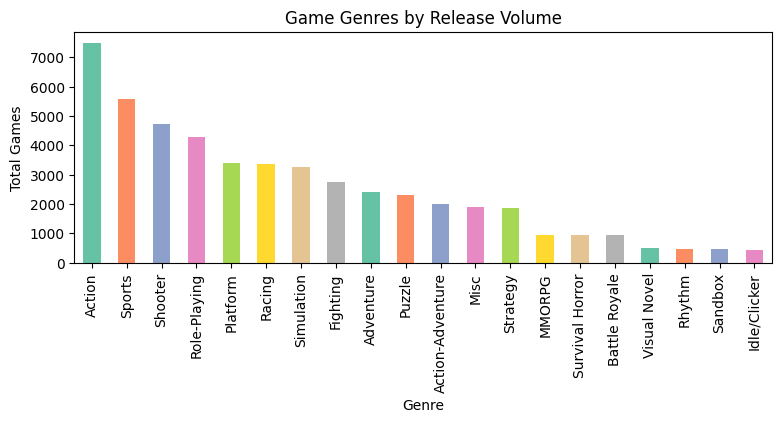

In [15]:
genre_counts = df['genre'].value_counts()
plt.figure(figsize=(9, 3))
genre_counts.plot(kind='bar', color=sns.color_palette('Set2'))

plt.title('Game Genres by Release Volume', fontsize=12)
plt.xlabel('Genre', fontsize=10)
plt.ylabel('Total Games', fontsize=10)

plt.show()

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
print(df.columns)

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer'],
      dtype='object')


In [17]:
# Dataset Describe
df.describe()

,platform_generation,year
count,50000.000000,50000.000000
mean,4.397120,2007.479640
std,3.256757,11.673832
min,0.000000,1985.000000
25%,0.000000,1998.000000
50%,5.000000,2008.000000
75%,7.000000,2017.000000
max,10.000000,2026.000000


### Variables Description

game_id: Unique identifier for each game record.

title: The specific name of the video game.

platform: The exact hardware platform the game was released on (e.g., PS5, Switch).

platform_type: The category of the hardware (Console, PC, Handheld, Mobile, etc.).

platform_maker: The parent company responsible for the platform (e.g., Sony, Microsoft).

platform_generation: The console generation timeline (numeric mapping 1-10).

genre: The primary gameplay category (comprising 20 distinct types, led by Action and Sports).

year: The release year of the game (ranging from 1980 to 2026).

publisher / developer: The corporate entities that funded, created, and published the title

### Check Unique Values for each variable.

In [18]:
print(df.nunique())

game_id                50000
title                   1391
platform                  33
platform_type              7
platform_maker             8
platform_generation       10
genre                     20
year                      42
publisher                 51
developer                 51
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()
if 'game_id' in df_clean.columns:
    df_clean.drop('game_id', axis=1, inplace=True)



### What all manipulations have you done and insights you found?

Zero Imputation Required: As verified in the previous step, the dataset contains no missing values, meaning no data imputation or row dropping was necessary. The structural integrity of the raw data is completely intact.

Dimensionality Reduction: Dropped the game_id column. Unique string identifiers hold no statistical variance and cannot be used in linear regression, hypothesis testing, or aggregations.

Feature Engineering: Created a new numerical variable called game_age by subtracting the release year from the dataset's maximum bound (2026). This will allow for more logical time-series analysis and correlation testing in the upcoming multivariate phase.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [20]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [21]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [22]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [23]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [24]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [25]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [26]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [27]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [28]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [29]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [30]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [31]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [32]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [33]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [34]:
# Pair Plot visualization code

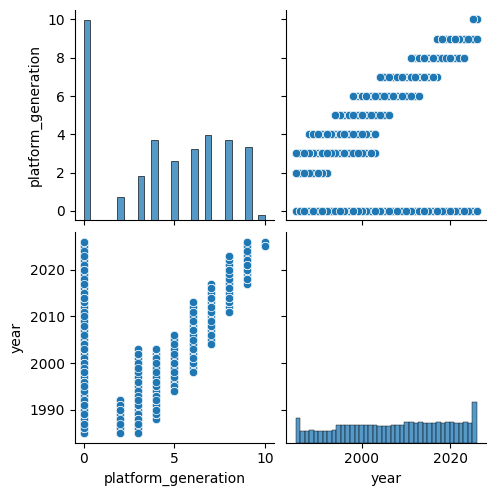

In [35]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [36]:
8882582016

8882582016